In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/Global YouTube Statistics.csv', encoding='latin1')

In [ ]:
df.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country of origin,Country,Abbreviation,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000.0,2.280000e+11,Music,T-Series,20082,India,india,IN,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000.0,0.000000e+00,Film & Animation,youtubemovies,1,United States,United States,US,...,NaN,2006.0,NaN,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000.0,2.836884e+10,Entertainment,MrBeast,741,United States,United States,US,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000.0,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,United States,US,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000.0,1.480000e+11,Shows,SET India,116536,India,India,IN,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [ ]:
df.shape

(1006, 29)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006 entries, 0 to 1005
Data columns (total 29 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     1006 non-null   int64  
 1   Youtuber                                 1006 non-null   object 
 2   subscribers                              1003 non-null   float64
 3   video views                              1006 non-null   float64
 4   category                                 951 non-null    object 
 5   Title                                    1006 non-null   object 
 6   uploads                                  1006 non-null   int64  
 7   Country of origin                        881 non-null    object 
 8   Country                                  881 non-null    object 
 9   Abbreviation                             881 non-null    object 
 10  channel_type                             974 non

In [ ]:
df.isnull().sum()

,0
rank,0
Youtuber,0
subscribers,3
video views,0
category,55
Title,0
uploads,0
Country of origin,125
Country,125
Abbreviation,125


In [ ]:
df.duplicated().sum()

np.int64(11)

In [ ]:
duplicates = df[df.duplicated()]
print(duplicates)

      rank                                           Youtuber  subscribers  \
995     12                                                WWE   96000000.0   
996     13                                             Gaming   93600000.0   
997     39  LooLoo Kids - Nursery Rhymes and Children's Songs   54000000.0   
998     40                                         Ed Sheeran   53500000.0   
999     41                                  Infobells - Hindi   53300000.0   
1000   620                                          MY FAMILY   15700000.0   
1001   779                                           The Dodo   14200000.0   
1002   787                                   Supercar Blondie   14100000.0   
1003   871                               Just For Laughs Gags   13300000.0   
1004   872                                   Kabita's Kitchen   13300000.0   
1005   873                                         BanderitaX   13300000.0   

       video views          category  \
995   7.742847e+10     

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['category'].isnull().sum()

np.int64(55)

In [ ]:
df['category'] = df['category'].fillna("Unknown")
df['category'].isnull().sum()
df['category'].value_counts()

,count
category,
Entertainment,238
Music,203
People & Blogs,131
Gaming,95
Comedy,70
Unknown,55
Education,46
Film & Animation,45
Howto & Style,40


In [ ]:
df['channel_type'].isnull().sum()

np.int64(32)

In [ ]:
df['channel_type'] = df['channel_type'].fillna("Unknown")
df['channel_type'].value_counts()

,count
channel_type,
Entertainment,304
Music,217
People,102
Games,100
Comedy,52
Education,50
Film,42
Howto,37
Unknown,32


In [ ]:
df['Country'] = df['Country'].str.strip().str.title()
df['Country of origin'] = df['Country of origin'].str.strip().str.title()

In [ ]:
is_identical = df['Country'].equals(df['Country of origin'])
print(f"Are the columns identical? {is_identical}")

Are the columns identical? True


In [ ]:
#drop country of origin column
df = df.drop(columns=['Country of origin'])

In [ ]:
df['Country'].isnull().sum()

np.int64(0)

In [ ]:
df['Country'] = df['Country'].fillna("Unknown")
df['Country'].value_counts()

,count
Country,
United States,315
India,170
Unknown,125
Brazil,62
United Kingdom,44
Mexico,33
Indonesia,28
Spain,22
Thailand,18


In [ ]:
df['subscribers_for_last_30_days'] = pd.to_numeric(df['subscribers_for_last_30_days'], errors='coerce')

In [ ]:
df['subscribers_for_last_30_days'].isnull().sum()

np.int64(337)

In [ ]:
df['subscribers_for_last_30_days'].fillna(0, inplace = True)

/tmp/ipykernel_1607/3758679453.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['subscribers_for_last_30_days'].fillna(0, inplace = True)


In [ ]:
df['subscribers_for_last_30_days'].head()

,subscribers_for_last_30_days
0,2000000.0
1,0.0
2,8000000.0
3,1000000.0
4,1000000.0


In [ ]:
df['subscribers_for_last_30_days'].isnull().sum()

np.int64(0)

In [ ]:
df['video_views_for_the_last_30_days'].fillna(0, inplace = True)
df['video_views_for_the_last_30_days'].isnull().sum()

/tmp/ipykernel_1607/4257352757.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['video_views_for_the_last_30_days'].fillna(0, inplace = True)


np.int64(0)

In [ ]:
#top 10 YouTube channels based on the number of subscribers
top_10_channels = df.nlargest(10, 'subscribers')
print(top_10_channels[['Youtuber', 'subscribers']])

                     Youtuber  subscribers
0                    T-Series  245000000.0
1              YouTube Movies  170000000.0
2                     MrBeast  166000000.0
3  Cocomelon - Nursery Rhymes  162000000.0
4                   SET India  159000000.0
5                       Music  119000000.0
6         ýýý Kids Diana Show  112000000.0
7                   PewDiePie  111000000.0
8                 Like Nastya  106000000.0
9               Vlad and Niki   98900000.0


In [ ]:
#top 10 countries by number of youtube channels
top_countries = df['Country'].value_counts().head(10)
print(top_countries)

Country
United States     315
India             170
Unknown           125
Brazil             62
United Kingdom     44
Mexico             33
Indonesia          28
Spain              22
Thailand           18
South Korea        17
Name: count, dtype: int64


In [ ]:
top_10_countries = (df[df['Country'] != 'Unknown']['Country'].value_counts().head(10))
print(top_10_countries)

Country
United States     315
India             170
Brazil             62
United Kingdom     44
Mexico             33
Indonesia          28
Spain              22
Thailand           18
South Korea        17
Russia             16
Name: count, dtype: int64


Visualizations

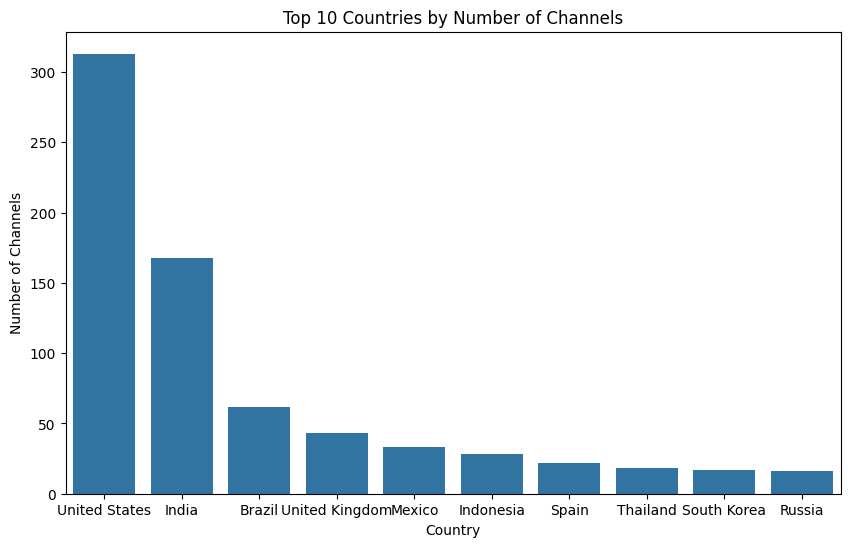

In [ ]:
#top 10 countries by number of channels
plt.figure(figsize=(10,6))
sns.barplot(top_10_countries)
plt.title('Top 10 Countries by Number of Channels')
plt.xlabel('Country')
plt.ylabel('Number of Channels')
plt.show()

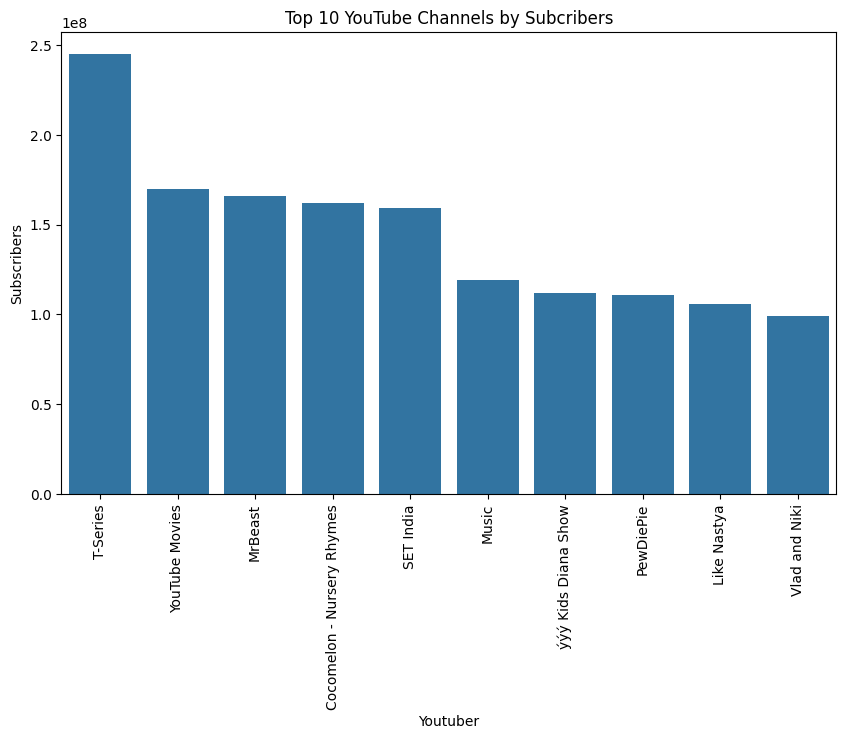

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='Youtuber',
    y='subscribers',
    data=top_10_channels
)
plt.title('Top 10 YouTube Channels by Subcribers')
plt.xlabel('Youtuber')
plt.ylabel('Subscribers')
plt.xticks(rotation=90)
plt.show()

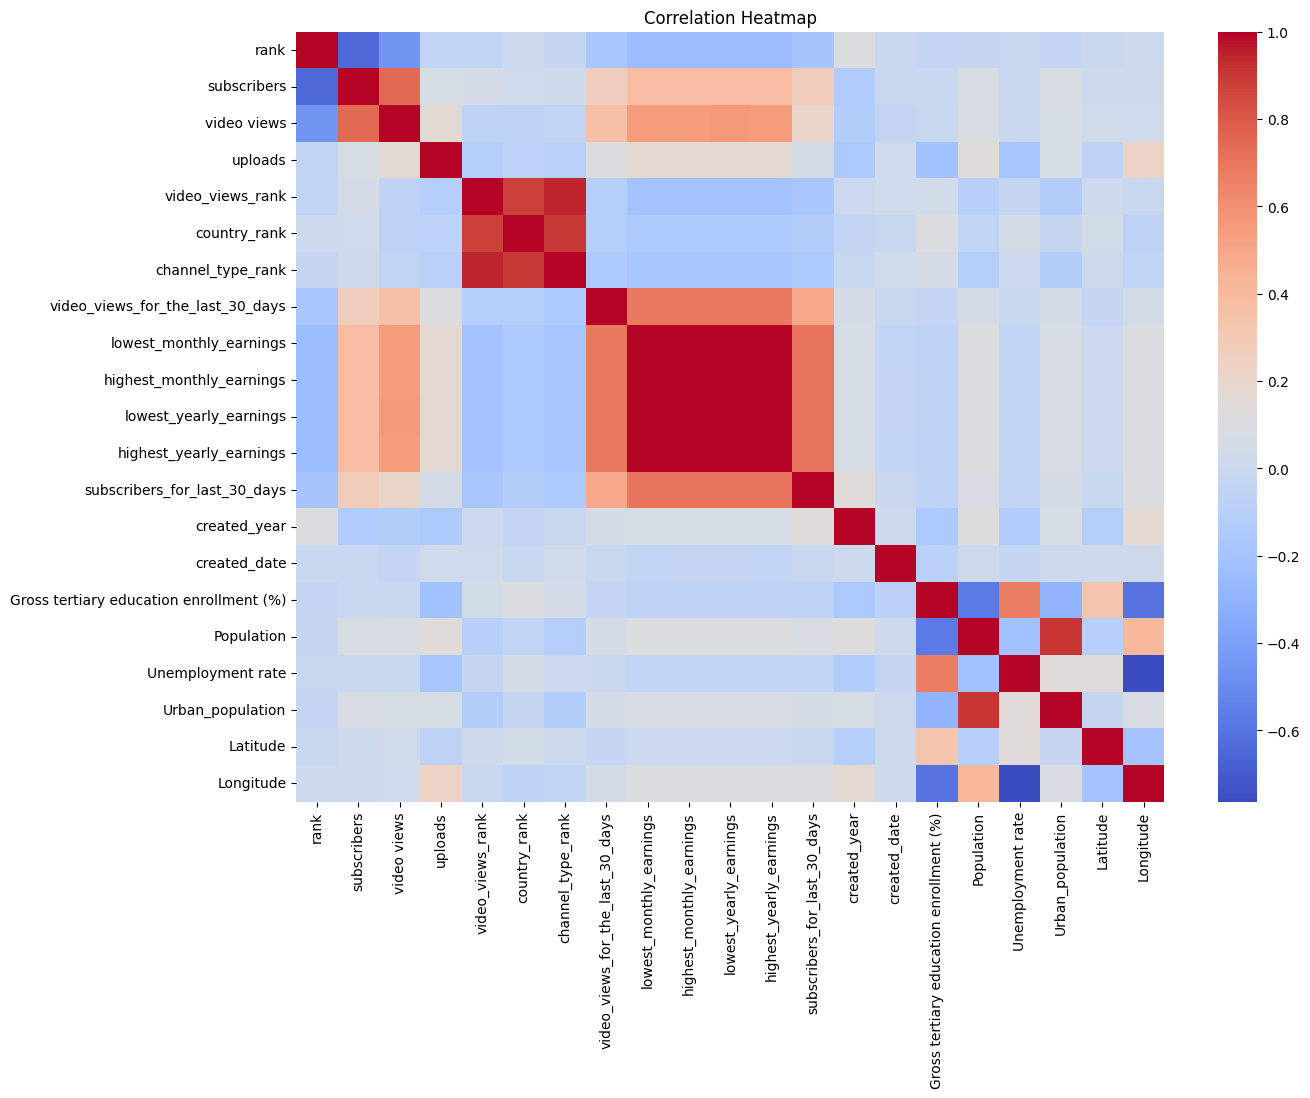

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

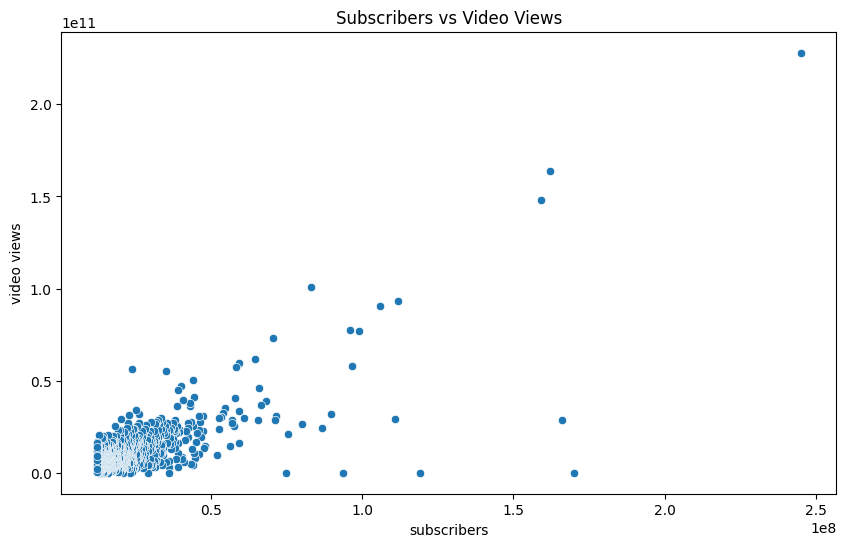

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['subscribers'],
    y=df['video views'],

)

plt.title("Subscribers vs Video Views")

plt.show()

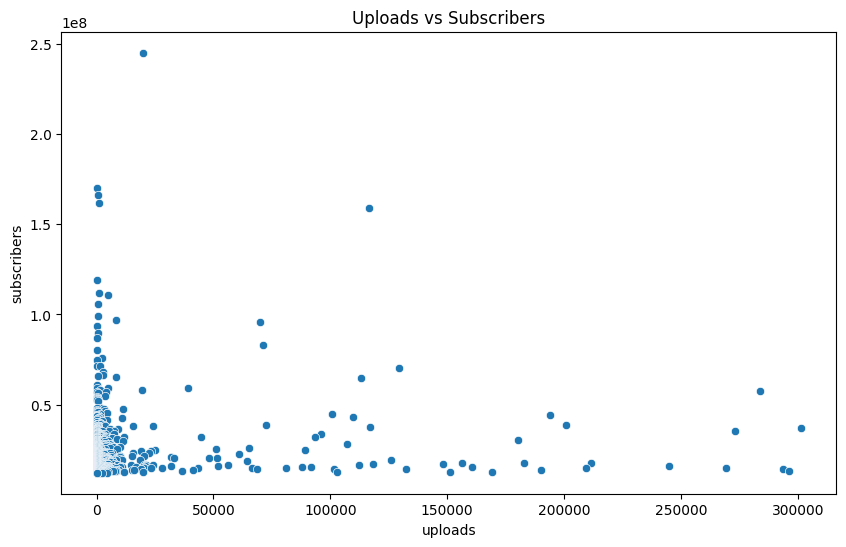

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='uploads',
    y='subscribers',
    data=df
)

plt.title("Uploads vs Subscribers")

plt.show()

In [11]:
channel_views = df.groupby('channel_type')['video_views_for_the_last_30_days'].sum().sort_values(ascending=False)
print(channel_views)

channel_type
Entertainment    6.386184e+10
Music            3.773526e+10
People           1.720830e+10
Education        1.003686e+10
Comedy           9.618215e+09
Games            8.668806e+09
Film             5.763538e+09
News             5.250126e+09
Sports           2.843109e+09
Howto            2.170354e+09
Animals          2.122043e+09
Tech             9.365210e+08
Autos            7.065205e+08
Nonprofit        1.951810e+08
Name: video_views_for_the_last_30_days, dtype: float64


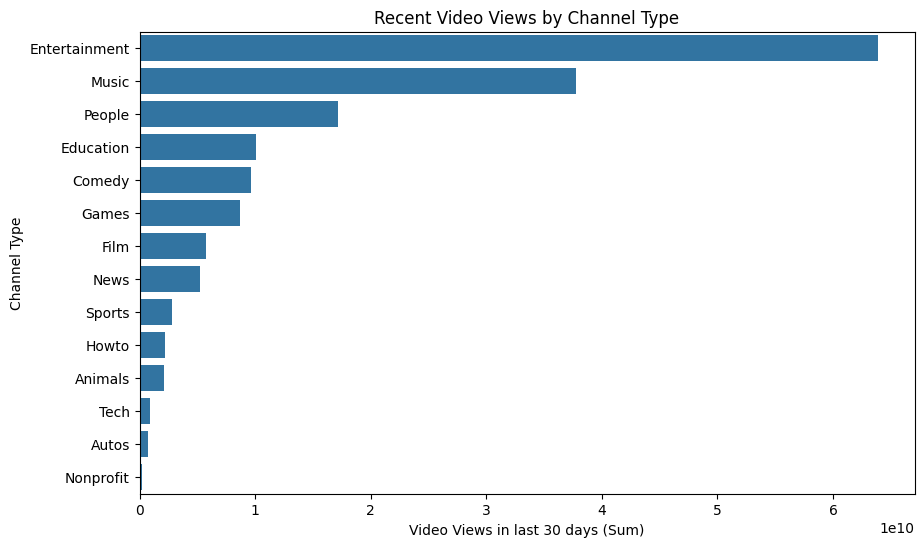

In [12]:
plt.figure(figsize=(10,6))
sns.barplot(x=channel_views.values, y=channel_views.index)
plt.xlabel('Video Views in last 30 days (Sum)')
plt.ylabel('Channel Type')
plt.title("Recent Video Views by Channel Type")
plt.show()

In [ ]:
bins = [0,2009,2014,2019, df['created_year'].max()]
labels = [
    'Before 2010',
    '2010-2014',
    '2015-2019',
    'After 2019'
]
df['creation_period'] = pd.cut(df['created_year'], bins=bins, labels=labels)


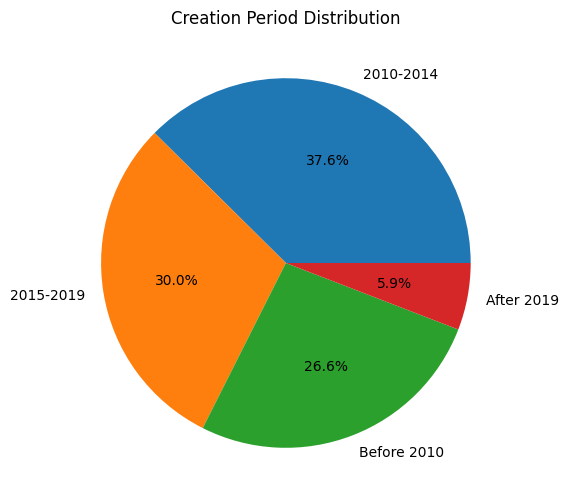

In [ ]:
plt.figure(figsize=(10,6))
creation_period_counts = df['creation_period'].value_counts()
plt.pie(creation_period_counts, labels = creation_period_counts.index, autopct='%1.1f%%')
plt.title('Creation Period Distribution')
plt.show()